In [ ]:
!pip install qiskit ipywidgets
!pip install pylatexenc
!pip install qiskit_aer

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 10.0 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e5446dd90d022ad7853da0c02adadea0ba6c41a03fddb33ce0d2586565b11130
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built py

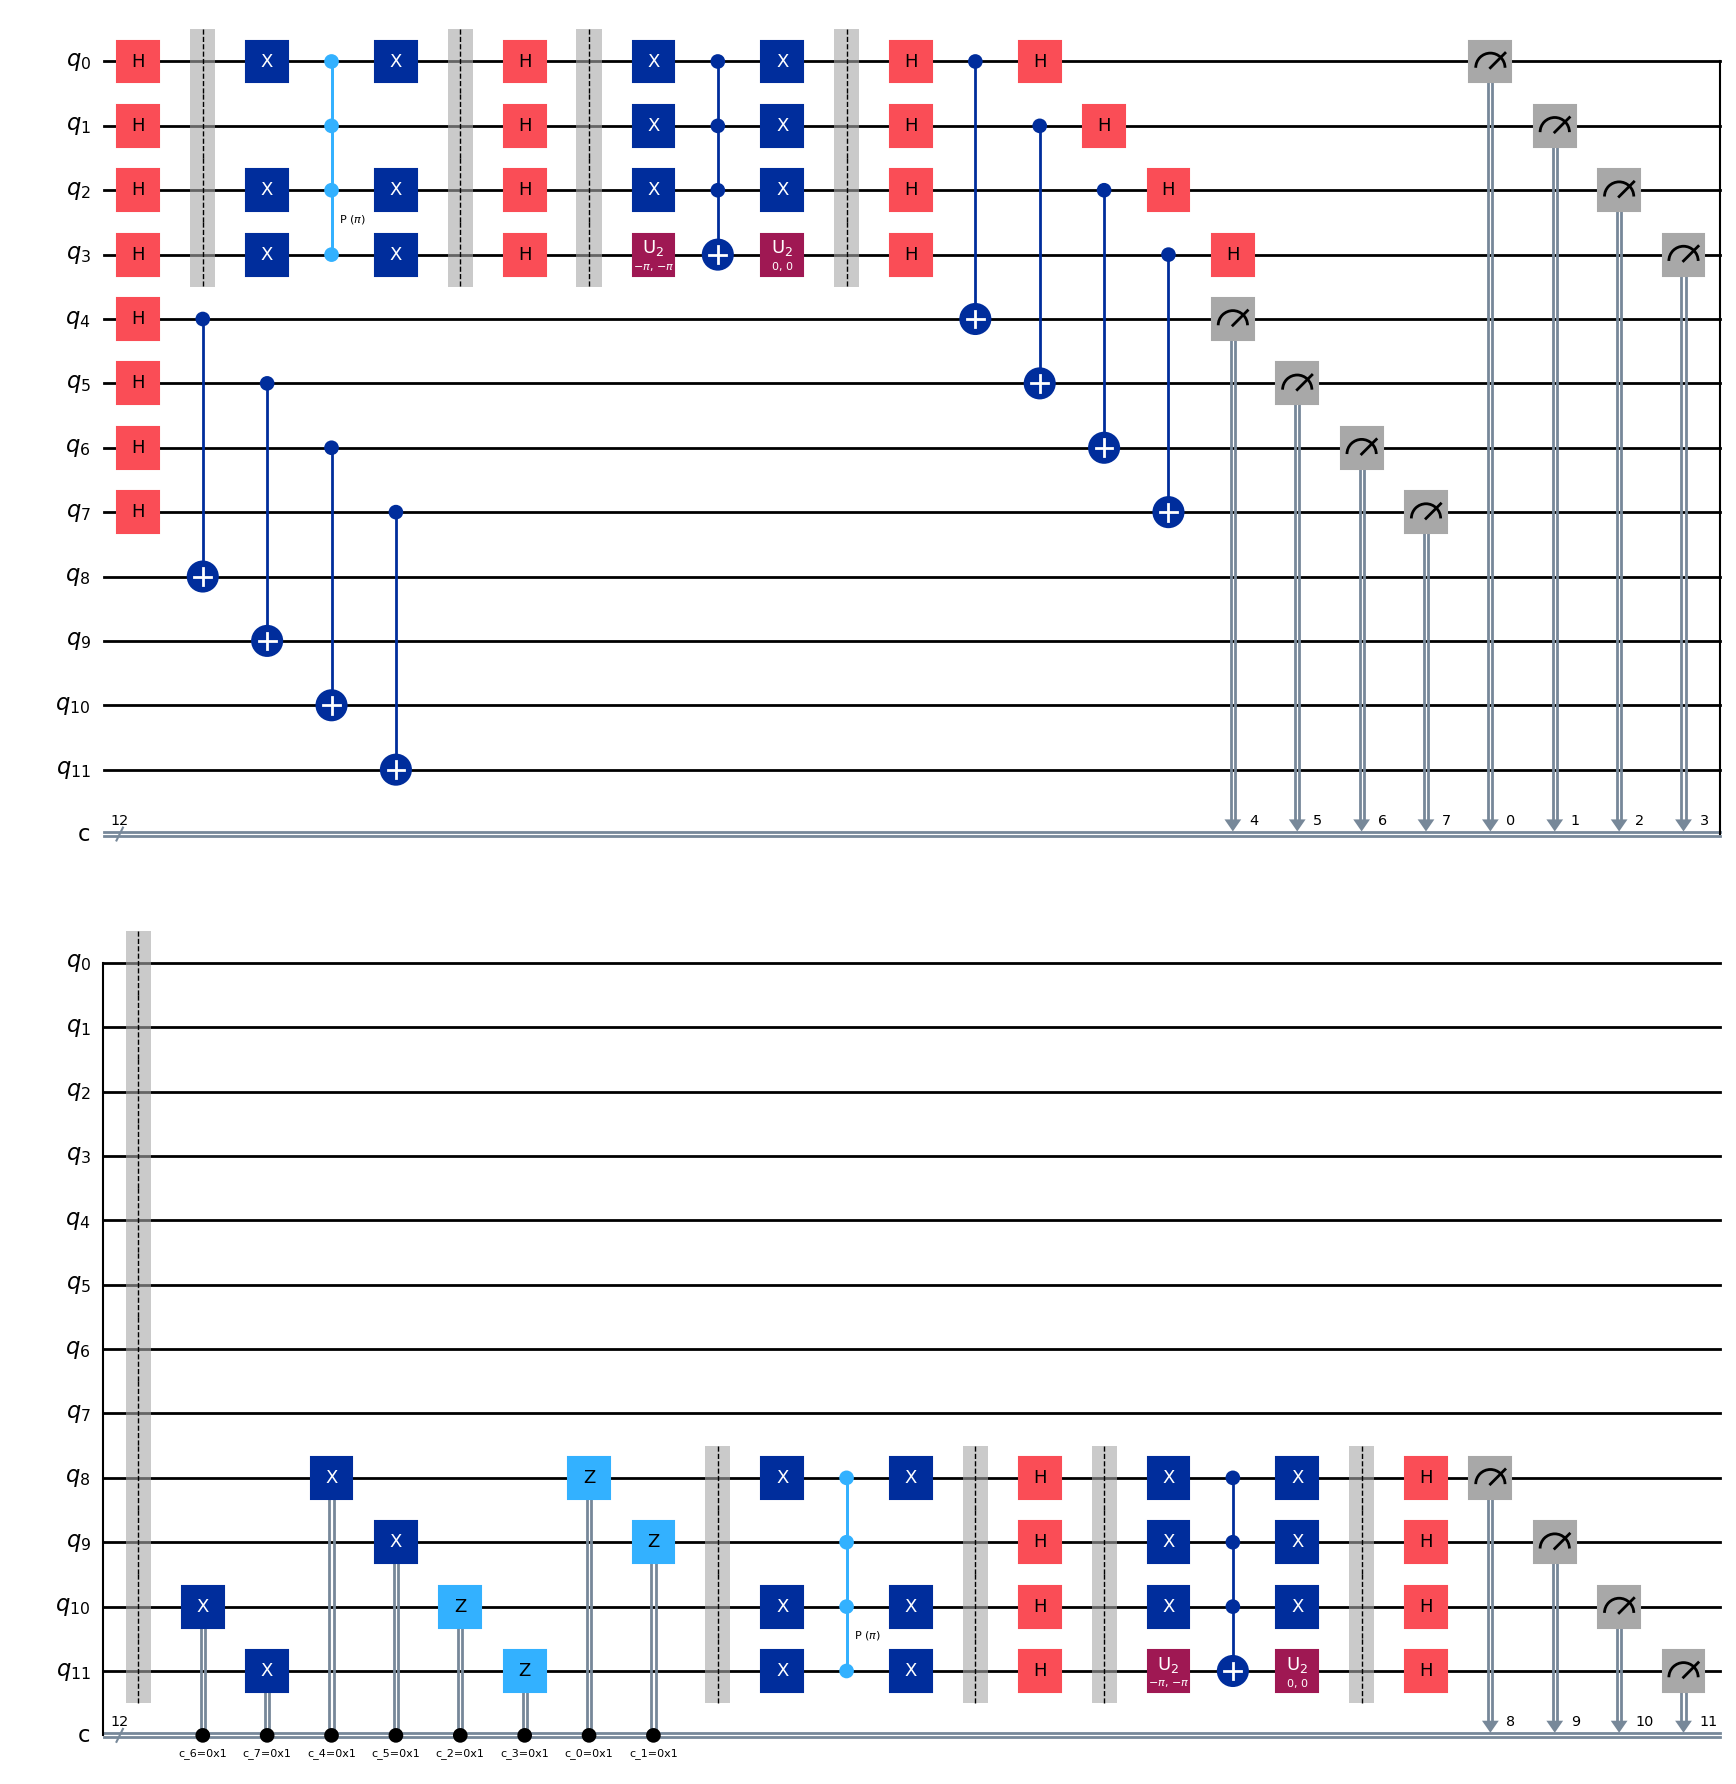

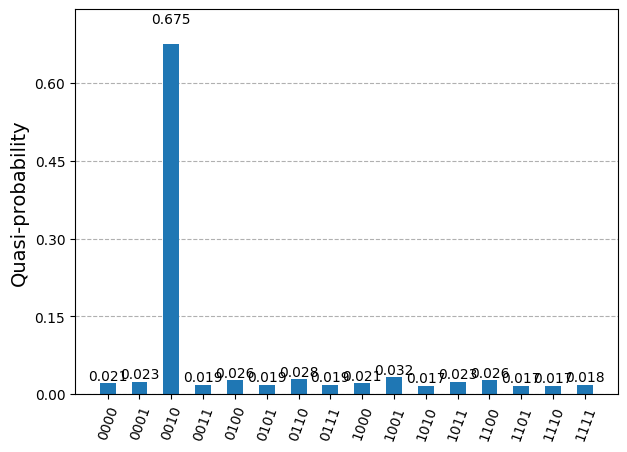

In [7]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_state_qsphere
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.circuit.library import GroverOperator
from math import pi
from qiskit import transpile
from qiskit_aer import noise
from qiskit.result import marginal_counts
from qiskit.visualization import plot_distribution

qc = QuantumCircuit(12,12)
qc.h(range(4))
qc.barrier(range(4))
grover_circuit = QuantumCircuit(4)
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])
grover_op = GroverOperator(mark_state, insert_barriers=True)
grover_circuit = grover_circuit.compose(grover_op)
qc = qc.compose(grover_circuit.decompose(), qubits=range(4))

Control = 0
Not = 4
qc.h(range(4,8))
qc.cx(range(4,8),range(8,12))
for i in range (4) :
  qc.cx(Control , Not)
  qc.h(Control)
  Control+=1
  Not+=1
qc.measure([4,5,6,7,0,1,2,3],[4,5,6,7,0,1,2,3])
qc.barrier()

for i in range(8, 12):
    qc.x(i).c_if(i - 4, 1)
    qc.z(i).c_if(i - 8, 1)

qc.barrier(range(8, 12))
grover_circuit = QuantumCircuit(4)
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])
grover_op = GroverOperator(mark_state, insert_barriers=True)
grover_circuit = grover_circuit.compose(grover_op)
qc = qc.compose(grover_circuit.decompose(), qubits=range(8, 12))

for i in range(8,12):
  qc.measure(i, i)
simulator_aer = AerSimulator(seed_simulator=42)
qc_aer = transpile(qc, simulator_aer)

display(qc_aer.draw('mpl'))

prob_1 = 0.001
prob_2 = 0.01
prob_3 = 0.1
error1 = noise.depolarizing_error(prob_1, 1)
error2 = noise.depolarizing_error(prob_2, 2)
error3 = noise.depolarizing_error(prob_3, 4)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error1, ['h', 'u2', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(error2, ['cx'])
noise_model.add_all_qubit_quantum_error(error3, ['mcp', 'mcx'])
basis_gates = noise_model.basis_gates
shots = 1024
noisy_result = simulator_aer.run(
    qc_aer,
    shots=shots,
    noise_model=noise_model,
    basis_gates=basis_gates
).result()
counts = noisy_result.get_counts()
marginal_result= marginal_counts(counts, indices=[8,9,10,11])
plot_distribution(marginal_result)
